# 2.DBSCAN 
- 225-11-30 接1. AutoRectify, 清理Ensemble繪圖只保留DB繪圖與清理步驟。


In [1]:
# 設定nb頁面佔滿瀏覽器寬度
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) # ex: width:1200px

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

# --- 1. 數據讀取與解析函式 ---

def load_yolo_submission(file_path):
    """
    讀取 YOLO 競賽提交檔，並解析成 DataFrame。
    欄位順序：[檔名, 類別, 信心指數, x1, y1, x2, y2]
    """
    try:
        # 由於數據沒有列名，我們手動指定它們
        df = pd.read_csv(
            file_path, 
            sep=' ', 
            header=None, 
            names=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
        )
        return df
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {file_path}")
        return None
    except Exception as e:
        print(f"讀取檔案時發生錯誤: {e}")
        return None

# --- 2. 數據處理與轉換函式 ---

def preprocess_data(df):
    """
    從 DataFrame 中提取病人ID和影像Z軸編號。
    """
    if df is None:
        return None

    # 提取病人ID (patient00##) 和 Z軸編號 (####)
    # 使用正規表達式提取：
    # patient(00\d{2}) -> 擷取 00xx 部分
    # _(\d{4}) -> 擷取四位數字部分
    df['patient_id'] = df['filename'].str.extract(r'(patient\d{4})')
    df['z_index'] = df['filename'].str.extract(r'_(\d{4})').astype(int)

    # 計算預測框的 Y 軸高度（用於視覺化）
    # y_center: 預測框的中心點 Y 座標
    # y_min: 預測框的最小 Y 座標 (y1)
    # y_max: 預測框的最大 Y 座標 (y2)
    df['y_min'] = df[['y1', 'y2']].min(axis=1) # 確保 y_min 總是較小的值
    df['y_max'] = df[['y1', 'y2']].max(axis=1) # 確保 y_max 總是較大的值
    df['y_center'] = (df['y_min'] + df['y_max']) / 2
    # X_
    df['x_min'] = df[['x1', 'x2']].min(axis=1)
    df['x_max'] = df[['x1', 'x2']].max(axis=1)
    df['x_center'] = (df['x_min'] + df['x_max']) / 2
    # W, H
    df['W'] = (df['x_max'] - df['x_min'])
    df['H'] = (df['y_max'] - df['y_min'])
    # score
    df['score'] = df['confidence'] * 10
    
    return df

# --- 3. 繪圖函式：Z軸高度分佈 ---

def plot_z_axis_distribution_ZY(df_processed, patient_id):
    """
    繪製特定病人的 Z軸 (影像編號) vs Y軸 (預測框上下線) 分佈圖。
    
    Args:
        df_processed (pd.DataFrame): 經過 preprocess_data 處理後的 DataFrame。
        patient_id (str): 要繪圖的病人ID (例如 'patient0091')。
    """
    if df_processed is None:
        return
        
    # 過濾出特定病人的數據
    patient_df = df_processed[df_processed['patient_id'] == patient_id].copy()

    if patient_df.empty:
        print(f"找不到病人ID: {patient_id} 的數據。")
        return

    # 確保按照 Z軸編號排序，以便繪圖線條連續
    patient_df = patient_df.sort_values(by='z_index')

    # 建立圖表
    fig, ax = plt.subplots(figsize=(15, 8))

    # 繪製每個預測框的 Y軸上下線作為一條垂直線
    # X軸: z_index (影像編號)
    # Y軸: y_min 到 y_max
    for index, row in patient_df.iterrows():
        # 繪製垂直線條 (Y軸的上下界線)
        # alpha=row['confidence'] 可以讓信心分數低的框更透明
        ax.plot(
            [row['z_index'], row['z_index']],  # Z軸座標
            [row['y_min'], row['y_max']],     # Y軸座標範圍
            color='blue', 
            alpha=row['confidence'],          # 根據信心分數調整透明度
            marker='_',                       # 在上下端點加一小橫線
            markersize=5,
            linewidth=1.5
        )
        
        # 繪製 Y 軸中心點
        ax.scatter(row['z_index'], row['y_center'], 
                   color='red', 
                   s=40 * row['confidence'] + 1, # 信心分數越高，點越大
                   zorder=5) # 確保中心點在最上層

    # 設定圖表標籤和標題
    ax.set_xlabel("Z-Axis (CT Image Index, e.g., 0150, 0151...)")
    ax.set_ylabel("Y-Axis Pixel Location (Top to Bottom)")
    ax.set_title(f"YOLO Bounding Box Y-Axis Distribution for Patient: {patient_id}")
    
    # 顯示網格線
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # 將 Y 軸反轉，通常在影像座標系中 Y=0 在頂部
    ax.invert_yaxis()
    
    plt.show()

    
    
    
def plot_z_axis_distribution_ZX(df_processed, patient_id):
    """
    繪製特定病人的 Z軸 (影像編號) vs X軸 (預測框左右邊線) 分佈圖。
    
    Args:
        df_processed (pd.DataFrame): 經過 preprocess_data 處理後的 DataFrame。
        patient_id (str): 要繪圖的病人ID (例如 'patient0091')。
    """
    if df_processed is None:
        return
        
    # 過濾出特定病人的數據
    patient_df = df_processed[df_processed['patient_id'] == patient_id].copy()

    if patient_df.empty:
        print(f"找不到病人ID: {patient_id} 的數據。")
        return

    # 確保按照 Z軸編號排序，以便繪圖線條連續
    patient_df = patient_df.sort_values(by='z_index')

    # 建立圖表
    fig, ax = plt.subplots(figsize=(15, 8))

    # 繪製每個預測框的 Y軸上下線作為一條垂直線
    # X軸: z_index (影像編號)
    # Y軸: y_min 到 y_max
    for index, row in patient_df.iterrows():
        # 繪製垂直線條 (Y軸的上下界線)
        # alpha=row['confidence'] 可以讓信心分數低的框更透明
        ax.plot(
            [row['z_index'], row['z_index']],  # Z軸座標
            [row['x_min'], row['x_max']],     # 切換成X軸座標範圍
            color='green', 
            alpha=row['confidence'],          # 根據信心分數調整透明度
            marker='_',                       # 在上下端點加一小橫線
            markersize=5,
            linewidth=1.5
        )
        
        # 繪製 Y 軸中心點
        ax.scatter(row['z_index'], row['x_center'], 
                   color='red', 
                   s=40 * row['confidence'] + 1, # 信心分數越高，點越大
                   zorder=5) # 確保中心點在最上層

    # 設定圖表標籤和標題
    ax.set_xlabel("Z-Axis (CT Image Index, e.g., 0150, 0151...)")
    ax.set_ylabel("X-Axis Pixel Location (Top to Bottom)")
    ax.set_title(f"YOLO Bounding Box X-Axis Distribution for Patient: {patient_id}")
    
    # 顯示網格線
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # 將 Y 軸反轉，通常在影像座標系中 Y=0 在頂部
    ax.invert_yaxis()
    
    plt.show()
    
    
    
    
    
# # --- 4. 執行流程範例 ---

# # 1. 將您的數據樣本存為 'submission_sample.txt'
# submission_file = DWBF_txt

# # # 為了讓程式碼可立即運行，我們先將您的樣本數據寫入檔案
# # sample_data = """patient0091_0200 0 0.6889 221 253 250 286
# # patient0079_0200 0 0.6125 228 247 256 269
# # patient0066_0180 0 0.7980 164 193 233 258
# # patient0099_0242 0 0.8067 154 248 217 314
# # patient0100_0244 0 0.7568 216 247 268 310
# # patient0100_0244 0 0.0678 243 249 267 275
# # patient0055_0217 0 0.7396 198 228 234 280
# # patient0088_0215 0 0.3395 217 266 233 281
# # patient0051_0263 0 0.7929 206 244 265 312
# # patient0052_0156 0 0.7687 237 231 279 280
# # patient0084_0162 0 0.8068 161 197 225 267
# # patient0073_0194 0 0.6492 227 231 258 265
# # patient0094_0206 0 0.5075 241 224 258 240
# # patient0054_0234 0 0.7638 221 263 260 317
# # patient0087_0164 0 0.7452 175 210 207 258
# # patient0089_0188 0 0.6553 195 266 230 321
# # patient0080_0185 0 0.8049 180 300 238 361
# # patient0066_0174 0 0.7814 170 195 227 256
# # patient0087_0184 0 0.7838 162 189 235 263
# # patient0052_0178 0 0.7721 256 222 307 290
# # patient0091_0196 0 0.6312 225 256 247 282
# # patient0098_0201 0 0.8010 178 240 228 295
# # patient0053_0174 0 0.5047 214 252 232 270
# # patient0054_0242 0 0.7682 218 260 265 318
# # patient0098_0199 0 0.7918 180 240 227 295
# # patient0088_0194 0 0.7887 199 270 253 335
# # """
# # with open(submission_file, 'w') as f:
# #     f.write(sample_data)


# # 1. 載入數據
# df_raw = load_yolo_submission(submission_file)

# # 2. 處理數據
# df_clean = preprocess_data(df_raw)

# # # 3. 選擇病人 ID 進行繪圖
# # # 您可以將這裡的 ID 換成您想檢查的任何病人 ID
# # target_patient = 'patient0100'

# # if df_clean is not None:
# #     print(f"\n正在繪製 {target_patient} 的 Z軸高度分佈圖...")
# #     plot_z_axis_distribution(df_clean, target_patient)

# Temp read CV TXT

In [3]:
fold_name = "DETR_1120_V2_AR4.txt"

DWBF_txt = f"predict_txt/{fold_name}"

submission_file = DWBF_txt

# 1. 載入數據
df_raw = load_yolo_submission(submission_file)

# 2. 處理數據
df_clean = preprocess_data(df_raw)

# 聚類分析


工作原理
定義鄰域：給定一個鄰域半徑 eps 和最小點數 min_samples，算法會檢查每個數據點周圍有多少個點在 eps 距離範圍內。
核心點、邊界點和噪音點：2-1 核心點：如果一個數據點周圍有超過 min_samples 個點在 eps 範圍內，則該點是核心點。2-2 邊界點：不滿足核心點條件，但在其他核心點的 eps 鄰域內的點。2-3 噪音點：既不是核心點，也不在任何核心點的鄰域內的點，標記為噪音點（label = -1）。
形成群集：從一個核心點開始，將所有相連的點（包括邊界點）歸入同一群集，直到不再有新的點可以加入該群集為止。
重複步驟：繼續檢查其他未被歸入群集的點，直到所有點都被處理。
 https://vocus.cc/article/66f95ffdfd89780001505bb8

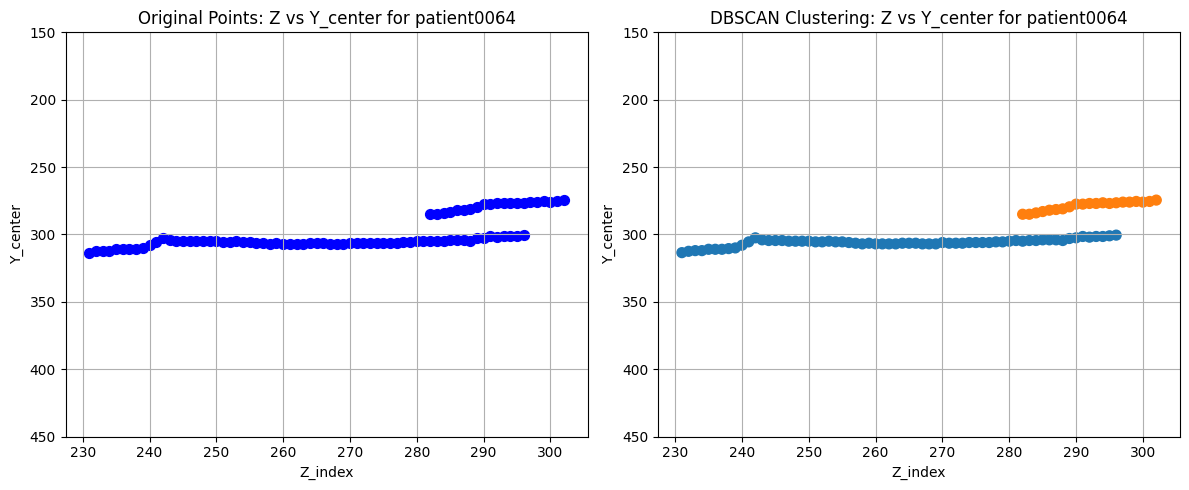

Clustering Results:
Number of clusters: 2
Number of noise points: 0
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1
 0 1 0 1 0 0 1 1 1 1 1 1 1]
Points: [[231.  313.5]
 [232.  312.5]
 [233.  312. ]
 [234.  312. ]
 [235.  311. ]
 [236.  311. ]
 [237.  311. ]
 [238.  310.5]
 [239.  310. ]
 [240.  308. ]
 [241.  305.5]
 [242.  302.5]
 [243.  304. ]
 [244.  304.5]
 [245.  304.5]
 [246.  304.5]
 [247.  305. ]
 [248.  305. ]
 [249.  305. ]
 [250.  305. ]
 [251.  305.5]
 [252.  305.5]
 [253.  305. ]
 [254.  305.5]
 [255.  305.5]
 [256.  306. ]
 [257.  306.5]
 [258.  307. ]
 [259.  306.5]
 [260.  307. ]
 [261.  307. ]
 [262.  307. ]
 [263.  307. ]
 [264.  306.5]
 [265.  306.5]
 [266.  306.5]
 [267.  307. ]
 [268.  307. ]
 [269.  307. ]
 [270.  306. ]
 [271.  306.5]
 [272.  306.5]
 [273.  306.5]
 [274.  306. ]
 [275.  306. ]
 [276.  306. ]
 [277.  306. ]
 [278.  305.5]
 [279.  305.5]
 [2

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN,HDBSCAN
import numpy as np

# 假設 df_clean 已經存在，從之前的對話載入
# 如果沒有，模擬數據或假設已載入
# 這裡假設 df_clean 是全局變數，如果沒有，請替換為實際載入
# df_clean = pd.read_csv('your_file.txt', sep=' ', header=None, names=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2'])
# df_clean['patient_id'] = df_clean['filename'].str.extract(r'(patient\d{4})')
# df_clean['z_index'] = df_clean['filename'].str.extract(r'_(\d{4})').astype(int)
# df_clean['y_min'] = df_clean[['y1', 'y2']].min(axis=1)
# df_clean['y_max'] = df_clean[['y1', 'y2']].max(axis=1)
# df_clean['y_center'] = (df_clean['y_min'] + df_clean['y_max']) / 2

# 過濾 patient0091
P_ID= 'patient0064'
patient_data = df_clean[df_clean['patient_id'] == P_ID ].copy()
patient_data = patient_data.sort_values('z_index')

# 提取 X = z_index, Y = y_center
Z_idx = patient_data['z_index'].values
cY = patient_data['y_center'].values
cX = patient_data['x_center'].values
x1 = patient_data['x1'].values
y1 = patient_data['y1'].values
x2 = patient_data['x2'].values
y2 = patient_data['y2'].values
# points = np.column_stack((Z_idx, cY, cX, x1, y1, x2, y2))
score = patient_data['score'].values
# points = np.column_stack((Z_idx, cY, cX, score))
W = patient_data['W'].values
H = patient_data['H'].values
# points = np.column_stack((Z_idx, cY,cX, score, W, H, x1, y1, x2, y2))
points = np.column_stack((Z_idx, cY))


# 原始繪圖
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(Z_idx, cY, c='blue', s=50)
ax1.set_title(f'Original Points: Z vs Y_center for {P_ID}')
ax1.set_xlabel('Z_index')
ax1.set_ylabel('Y_center')
ax1.grid(True)

# --- 【修正處】強制設定 Y 軸範圍並反轉 ---
# 即使共享 Y 軸，也強制設定範圍並反轉，確保所有子圖統一
ax1.set_ylim(450, 150) # 注意：這裡的 max, min 順序是反的！
                                 # (y_lim_max 在第一個參數，讓它變成 Y 軸頂部)
            
# 聚類：使用 DBSCAN metric= euclidean cosine cityblock, algorithm{‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}, default=’auto’ 
db = DBSCAN(eps=10, min_samples=10, metric='euclidean', algorithm='brute').fit(points)  # eps 和 min_samples 可調整 鄰域半徑 eps 和最小點數 min_samples
labels = db.labels_

# 聚類繪圖
colors = ['red' if l == -1 else f'C{l}' for l in labels]
ax2.scatter(Z_idx, cY, c=colors, s=50)
ax2.set_title(f'DBSCAN Clustering: Z vs Y_center for {P_ID}')
ax2.set_xlabel('Z_index')
ax2.set_ylabel('Y_center')
ax2.grid(True)
ax2.set_ylim(450, 150)


plt.tight_layout()
plt.savefig(f'clustering_result_{P_ID}.png')
plt.show()

# 輸出聚類結果
print("Clustering Results:")
print(f"Number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Number of noise points: {list(labels).count(-1)}")
print(f"Labels: {labels}")
print(f"Points: {points}")

# DBSCAN 分群樣本

Patient patient0051: Clusters = 3, Noise = 0
Patient patient0052: Clusters = 2, Noise = 0
Patient patient0053: Clusters = 3, Noise = 0
Patient patient0054: Clusters = 3, Noise = 0
Patient patient0055: Clusters = 6, Noise = 0
Patient patient0056: Clusters = 2, Noise = 0
Patient patient0057: Clusters = 2, Noise = 0
Patient patient0058: Clusters = 3, Noise = 0
Patient patient0059: Clusters = 3, Noise = 0
Patient patient0060: Clusters = 3, Noise = 0
Patient patient0061: Clusters = 3, Noise = 0
Patient patient0062: Clusters = 3, Noise = 0
Patient patient0063: Clusters = 3, Noise = 0
Patient patient0064: Clusters = 2, Noise = 0
Patient patient0065: Clusters = 6, Noise = 0
Patient patient0066: Clusters = 2, Noise = 0
Patient patient0067: Clusters = 4, Noise = 0
Patient patient0068: Clusters = 5, Noise = 0
Patient patient0069: Clusters = 4, Noise = 0
Patient patient0070: Clusters = 2, Noise = 0
Patient patient0071: Clusters = 2, Noise = 0
Patient patient0072: Clusters = 3, Noise = 0
Patient pa

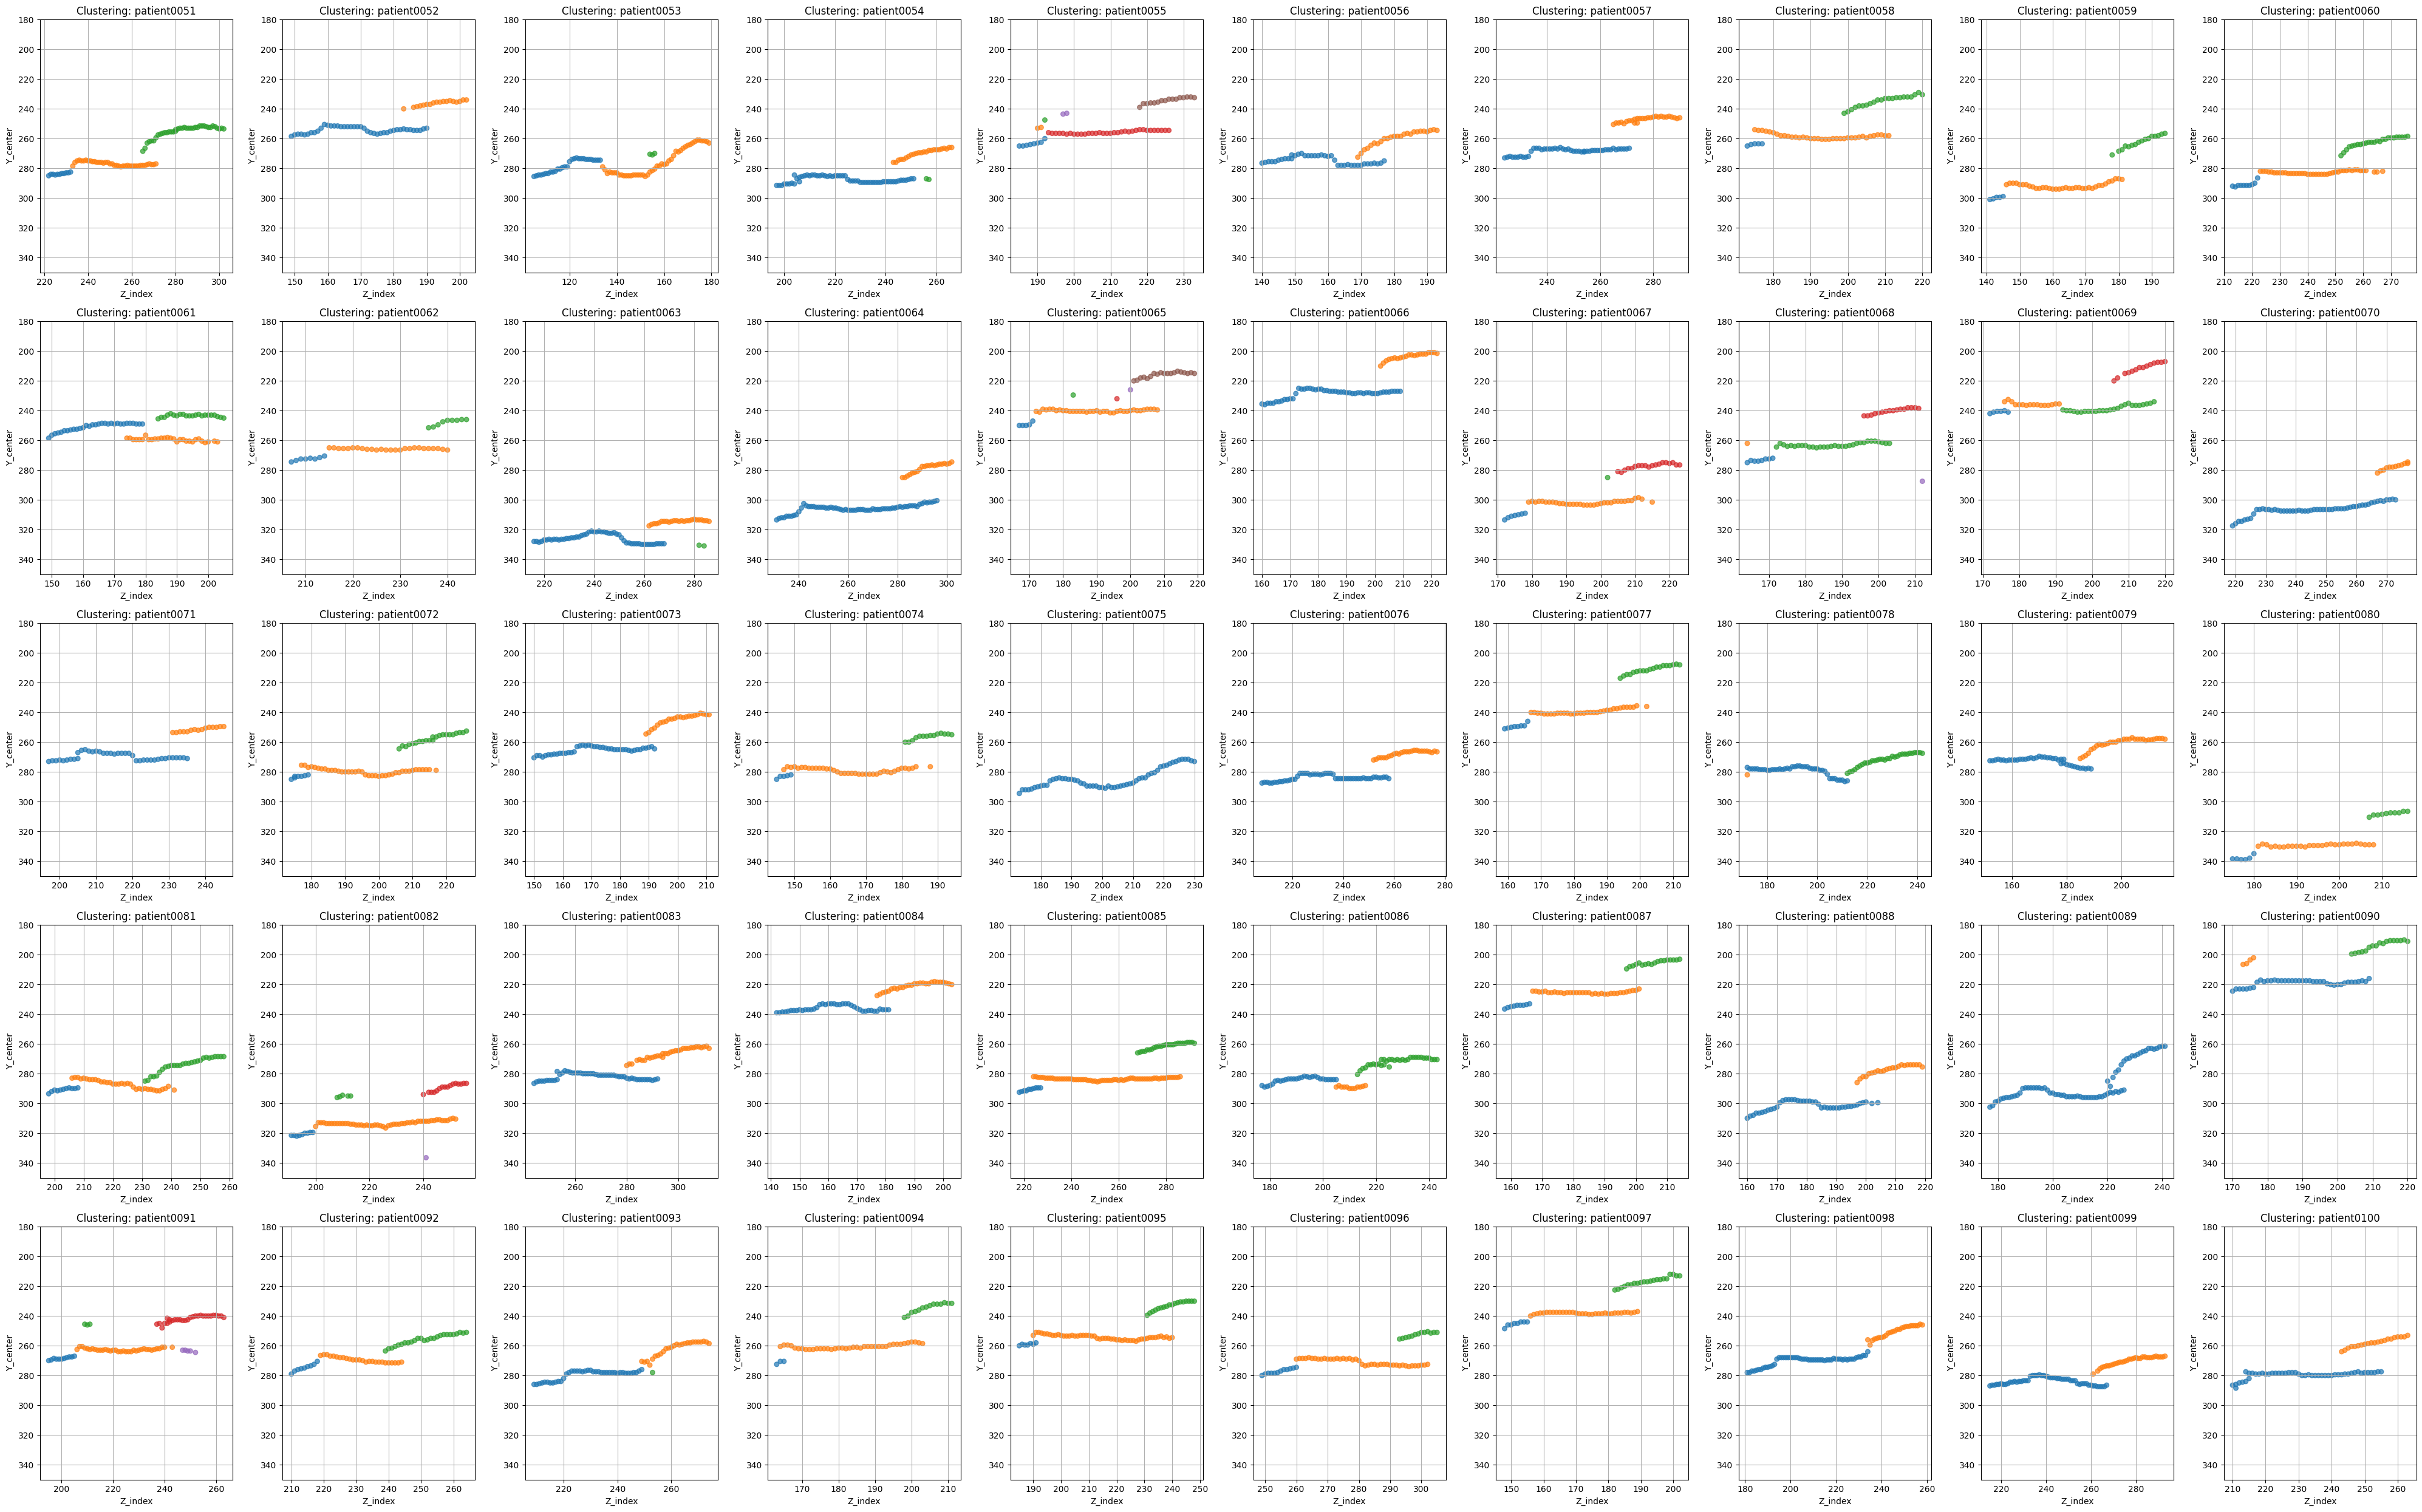

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np

# 假設 df_clean 已經存在，從之前的對話載入

# 擴展代碼：對 patient0051~patient0100 進行子圖繪圖
patients = [f'patient{i:04d}' for i in range(51, 101)]
n_patients = len(patients)
n_rows = 5
n_cols = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 25))
axes = axes.ravel()

for idx, p_id in enumerate(patients):
    ax_pair = axes[idx]
    patient_data = df_clean[df_clean['patient_id'] == p_id].copy()
    patient_data = patient_data.sort_values('z_index')
    
    if patient_data.empty:
        ax_pair.text(0.5, 0.5, f'No data for {p_id}', ha='center', va='center')
        ax_pair.set_title(p_id)
        continue
    
    X = patient_data['z_index'].values
    Y = patient_data['y_center'].values
#     cX = patient_data['x_center'].values
    points = np.column_stack((X, Y,))
    
#     # 原始繪圖 (左側)
#     ax_pair.scatter(X, Y, c='blue', s=50)
#     ax_pair.set_title(f'Original: {p_id}')
#     ax_pair.set_xlabel('Z_index')
#     ax_pair.set_ylabel('Y_center')
#     ax_pair.set_ylim(450, 150)
#     ax_pair.grid(True)
    
    # 聚類繪圖 (右側) - 但由於只有一個 ax，我們在同一個 ax 上畫兩個
    # 為了拼圖，我們在同一個 ax 上畫原始 (藍) + 聚類 (彩色)
    db = DBSCAN(eps=4, min_samples=1).fit(points)
    labels = db.labels_
    colors = ['red' if l == -1 else f'C{l}' for l in labels]
    ax_pair.scatter(X, Y, c=colors, s=30, alpha=0.7)  # 覆蓋原始點
    ax_pair.set_title(f'Clustering: {p_id}')
    ax_pair.set_xlabel('Z_index')
    ax_pair.set_ylabel('Y_center')
    ax_pair.set_ylim(350, 180)
    ax_pair.grid(True)
    
    # 輸出聚類結果
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Patient {p_id}: Clusters = {n_clusters}, Noise = {n_noise}") # , Labels = {labels}")

plt.tight_layout()
plt.savefig('all_patients_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# DB clean V1
##### 接續步驟，若一位病人分析的各群的點數若小於4，則將該群從原始df_clean中剔除，

patient0051: 刪除 0 點, 保留 89 點
patient0052: 刪除 0 點, 保留 60 點
patient0053: 刪除 3 點, 保留 75 點
patient0054: 刪除 2 點, 保留 81 點
patient0055: 刪除 5 點, 保留 58 點
patient0056: 刪除 0 點, 保留 64 點
patient0057: 刪除 0 點, 保留 77 點
patient0058: 刪除 0 點, 保留 64 點
patient0059: 刪除 0 點, 保留 57 點
patient0060: 刪除 0 點, 保留 77 點
patient0061: 刪除 0 點, 保留 82 點
patient0062: 刪除 0 點, 保留 43 點
patient0063: 刪除 2 點, 保留 78 點
patient0064: 刪除 0 點, 保留 87 點
patient0065: 刪除 3 點, 保留 61 點
patient0066: 刪除 0 點, 保留 71 點
patient0067: 刪除 1 點, 保留 61 點
patient0068: 刪除 2 點, 保留 56 點
patient0069: 刪除 0 點, 保留 62 點
patient0070: 刪除 0 點, 保留 67 點
patient0071: 刪除 0 點, 保留 55 點
patient0072: 刪除 0 點, 保留 69 點
patient0073: 刪除 0 點, 保留 66 點
patient0074: 刪除 0 點, 保留 58 點
patient0075: 刪除 0 點, 保留 58 點
patient0076: 刪除 0 點, 保留 77 點
patient0077: 刪除 0 點, 保留 61 點
patient0078: 刪除 1 點, 保留 72 點
patient0079: 刪除 0 點, 保留 72 點
patient0080: 刪除 0 點, 保留 44 點
patient0081: 刪除 0 點, 保留 74 點
patient0082: 刪除 6 點, 保留 78 點
patient0083: 刪除 0 點, 保留 83 點
patient0084: 刪除 0 點, 保留 67 點
patient0085: 刪

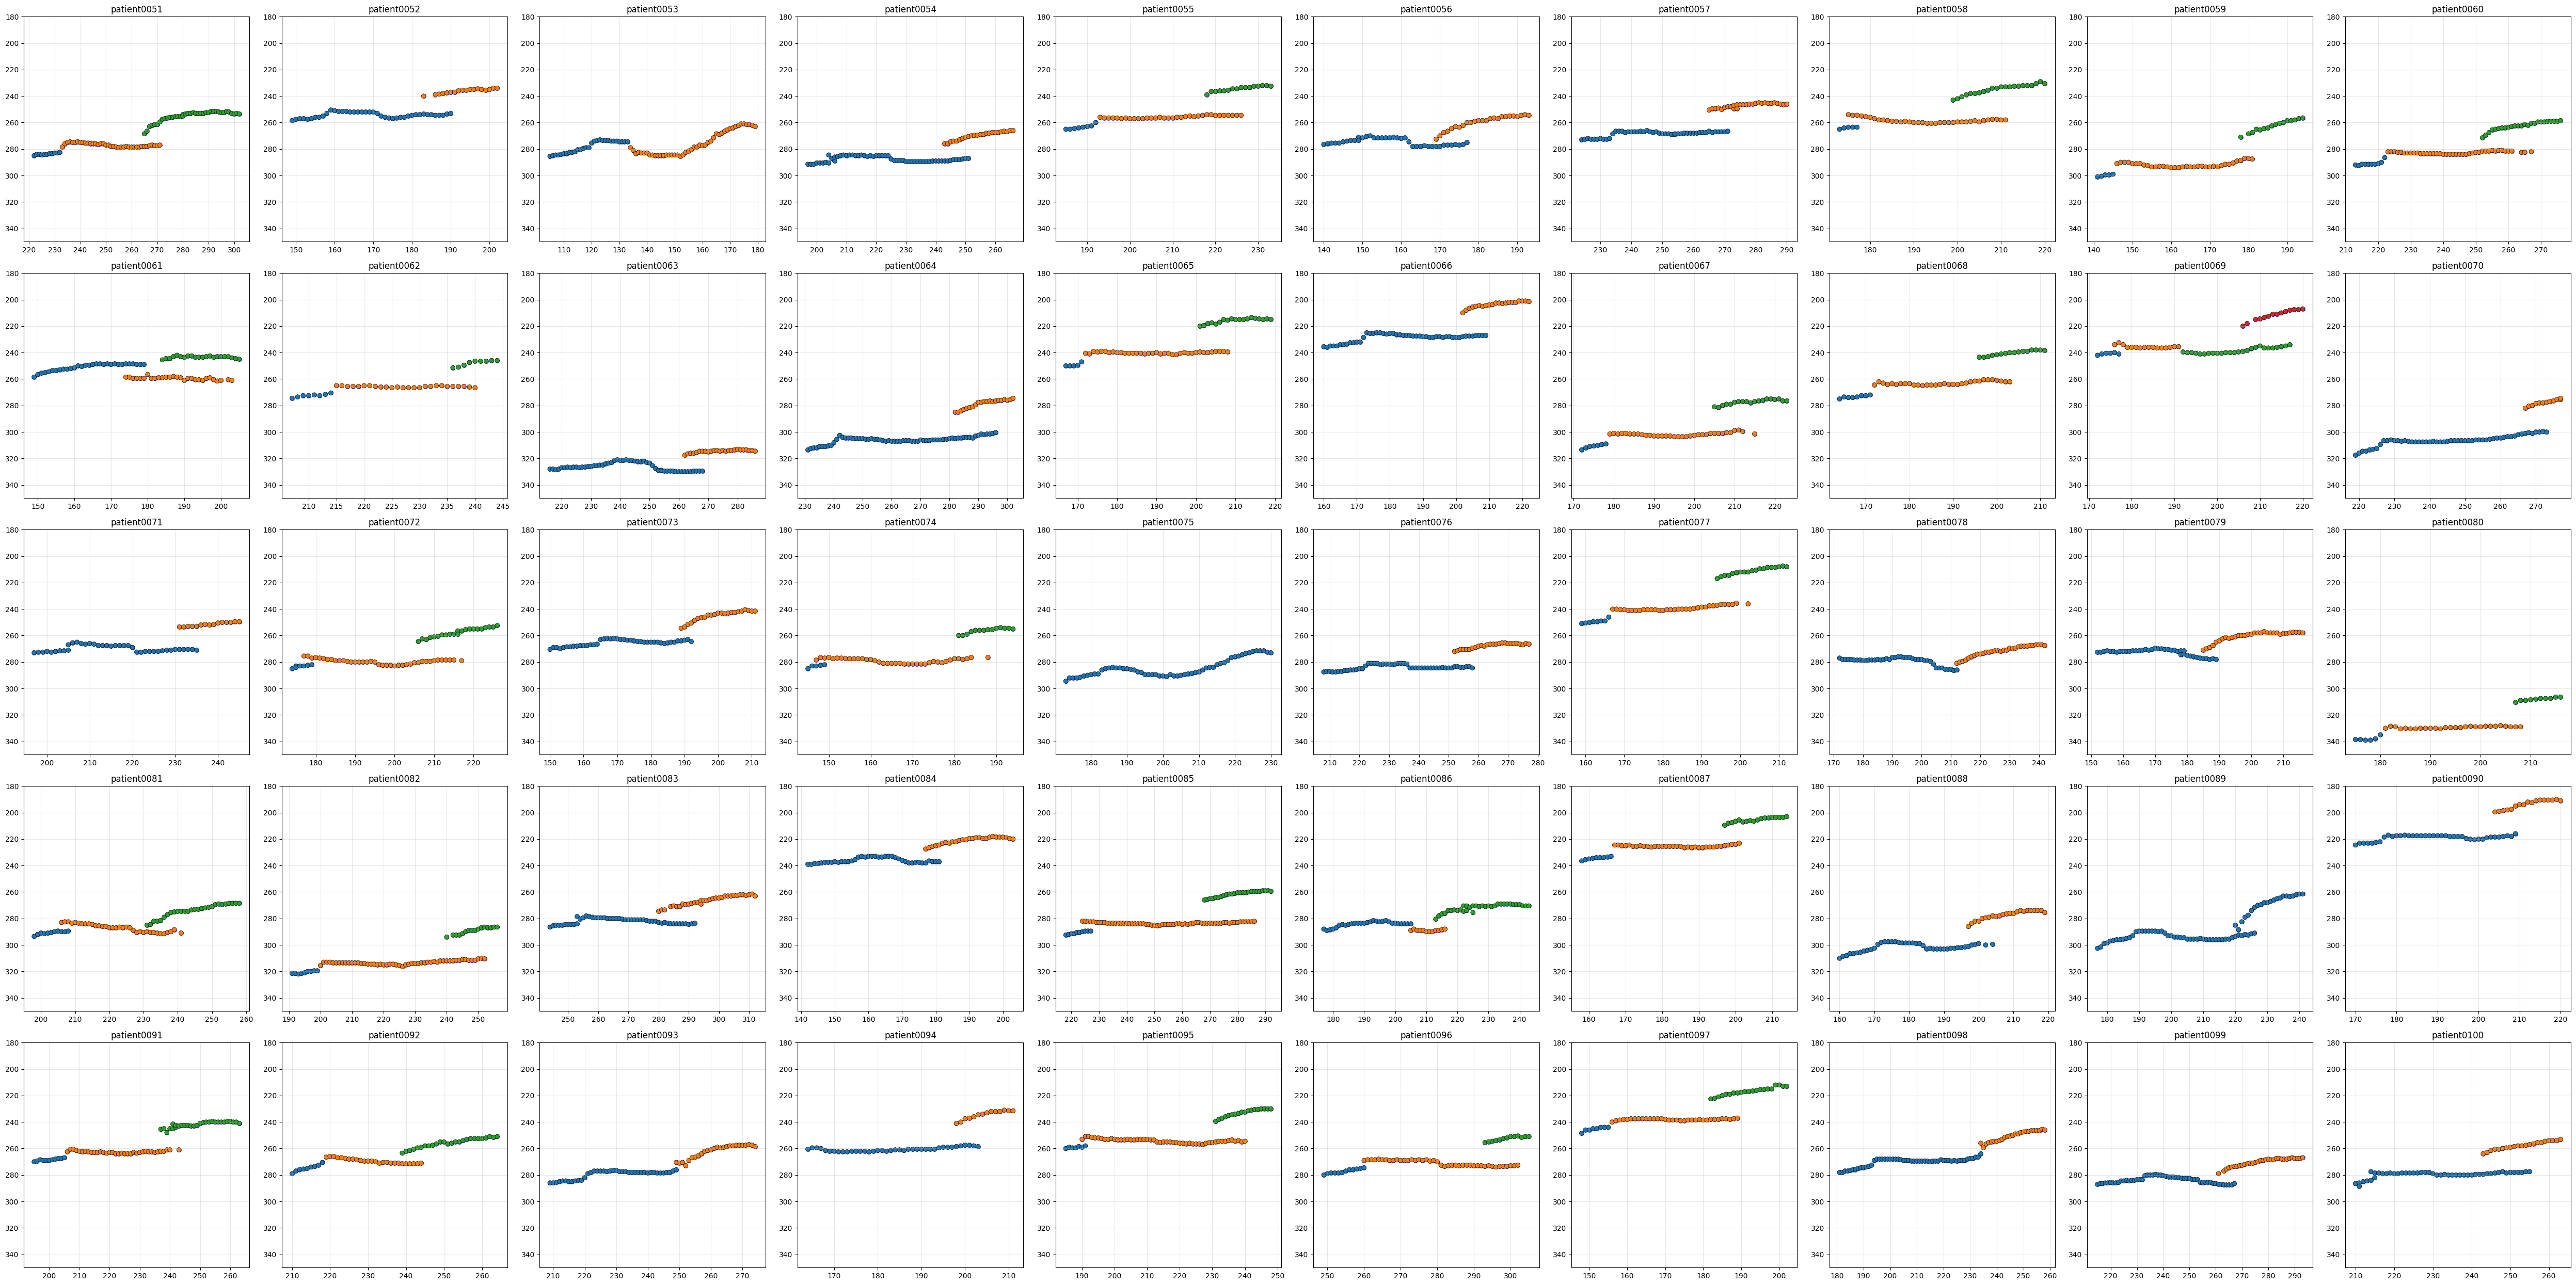

大圖已儲存: all_patients_clustering_updated.png
剩餘框：3433


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np
import re
import os

# 假設 df_clean 已存在，從用戶代碼模擬載入或定義
# 由於 REPL，假設之前有 df_clean，如果沒有，重新定義模擬數據
DBSCAN_updated_V1_name = "DBSCAN_clean_1130_v1.txt"



# 現在進行批量聚類和剔除
deleted_per_patient = {}
updated_points = []

for P_ID in patients:
    patient_data = df_clean[df_clean['patient_id'] == P_ID].copy()
    if patient_data.empty:
        continue
    patient_data = patient_data.sort_values('z_index')
    
    X = patient_data['z_index'].values
    Y = patient_data['y_center'].values
#     cX = patient_data['x_center'].values
    points = np.column_stack((X, Y))
    
    # 聚類
    db = DBSCAN(eps=4, min_samples=1).fit(points)
    labels = db.labels_
    
    # 找出每個簇的大小
    cluster_sizes = {}
    for label in set(labels):
        if label != -1:
            size = sum(labels == label)
            cluster_sizes[label] = size
    
    # 剔除大小 <4 的簇
    if P_ID in ['patient0082','patient0091']:
        keep_n = 5
    else:
        keep_n = 4
    keep_mask = np.zeros(len(labels), dtype=bool)
    deleted_count = 0
    for i, label in enumerate(labels):
        if label == -1 or (label in cluster_sizes and cluster_sizes[label] > keep_n):
            keep_mask[i] = True
        else:
            deleted_count += 1
    
    # 更新 patient_data
    patient_filtered = patient_data[keep_mask].copy()
    deleted_per_patient[P_ID] = deleted_count
    updated_points.append(patient_filtered)
    
    print(f"{P_ID}: 刪除 {deleted_count} 點, 保留 {len(patient_filtered)} 點")

# 合併更新後的數據
df_updated = pd.concat(updated_points, ignore_index=True) if updated_points else pd.DataFrame()

# # 顯示每個病人刪除數
# print("\n每個病人刪除點數:")
# for p, d in deleted_per_patient.items():
#     print(f"{p}: {d}")

total_deleted = sum(deleted_per_patient.values())
print(f"\n總刪除點數: {total_deleted}")

# 另存新 txt 檔案 (模擬原始格式)
output_file = DBSCAN_updated_V1_name
if not df_updated.empty:
    df_output = df_updated[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']].copy()
    df_output[['x1', 'y1', 'x2', 'y2']] = df_output[['x1', 'y1', 'x2', 'y2']].astype(int)
    df_output.to_csv(output_file, sep=' ', index=False, header=False, float_format='%.4f')
    print(f"\n新檔案已儲存: {output_file}")
else:
    print("無數據可儲存")

# 繪圖大圖 (10x5 網格)
fig, axes = plt.subplots(5, 10, figsize=(50, 25))
axes = axes.ravel()

for i, P_ID in enumerate(patients):
    ax = axes[i]
    patient_data = df_updated[df_updated['patient_id'] == P_ID].copy()
    if patient_data.empty:
        ax.text(0.5, 0.5, 'No Data', ha='center')
        continue
    
    patient_data = patient_data.sort_values('z_index')
    X = patient_data['z_index'].values
    Y = patient_data['y_center'].values
    points = np.column_stack((X, Y))
    
    db = DBSCAN(eps=4, min_samples=1).fit(points)
    labels = db.labels_
    colors = ['red' if l == -1 else f'C{l}' for l in labels]
    
    ax.scatter(X, Y, c='blue', s=30, alpha=0.6, label='Original')
    ax.scatter(X, Y, c=colors, s=40, edgecolors='black', linewidth=0.5, label='Clustered')
    ax.set_title(P_ID)
    ax.set_ylim(350, 180)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_patients_clustering_updated.png', dpi=150, bbox_inches='tight')
plt.show()

print("大圖已儲存: all_patients_clustering_updated.png")
print(f"剩餘框：{len(df_updated)}")

In [7]:
df_clean = df_updated

# DB clean V2
### 接續步驟，
###### 另外寫一個新的處理function同樣使用已經處理好的df_clean當作輸入，若一位病人DBSCAN分析後的各群的點數若大於10個，第一：則將該群中在同一個Z軸位置的重複框Y軸值較小者( patient_data['y_center'])從原始df_clean中剔除。第二：刪除該群中若有在Z軸上離主體間隔超過1格以上的不連續離群點。最後同樣每個病人子圖與合併大圖顯示，並列印每個病人被刪除多少重複點點以及離群點，最後另存新的txt檔案。


patient0051: 刪除重複 0, 離群 0, 簇數 3
patient0052: 刪除重複 0, 離群 1, 簇數 2
patient0053: 刪除重複 0, 離群 0, 簇數 2
patient0054: 刪除重複 0, 離群 0, 簇數 2
patient0055: 刪除重複 0, 離群 0, 簇數 3
patient0056: 刪除重複 0, 離群 0, 簇數 2
patient0057: 刪除重複 0, 離群 0, 簇數 2
patient0058: 刪除重複 0, 離群 0, 簇數 3
patient0059: 刪除重複 0, 離群 1, 簇數 3
patient0060: 刪除重複 0, 離群 3, 簇數 3
patient0061: 刪除重複 0, 離群 2, 簇數 3
patient0062: 刪除重複 0, 離群 0, 簇數 3
patient0063: 刪除重複 0, 離群 0, 簇數 2
patient0064: 刪除重複 0, 離群 0, 簇數 2
patient0065: 刪除重複 0, 離群 0, 簇數 3
patient0066: 刪除重複 0, 離群 0, 簇數 2
patient0067: 刪除重複 0, 離群 1, 簇數 3
patient0068: 刪除重複 0, 離群 0, 簇數 3
patient0069: 刪除重複 0, 離群 2, 簇數 4
patient0070: 刪除重複 0, 離群 0, 簇數 2
patient0071: 刪除重複 0, 離群 0, 簇數 2
patient0072: 刪除重複 0, 離群 1, 簇數 3
patient0073: 刪除重複 0, 離群 0, 簇數 2
patient0074: 刪除重複 0, 離群 1, 簇數 3
patient0075: 刪除重複 0, 離群 0, 簇數 1
patient0076: 刪除重複 0, 離群 0, 簇數 2
patient0077: 刪除重複 0, 離群 1, 簇數 3
patient0078: 刪除重複 0, 離群 0, 簇數 2
patient0079: 刪除重複 0, 離群 0, 簇數 2
patient0080: 刪除重複 0, 離群 0, 簇數 3
patient0081: 刪除重複 0, 離群 1, 簇數 3
patient0

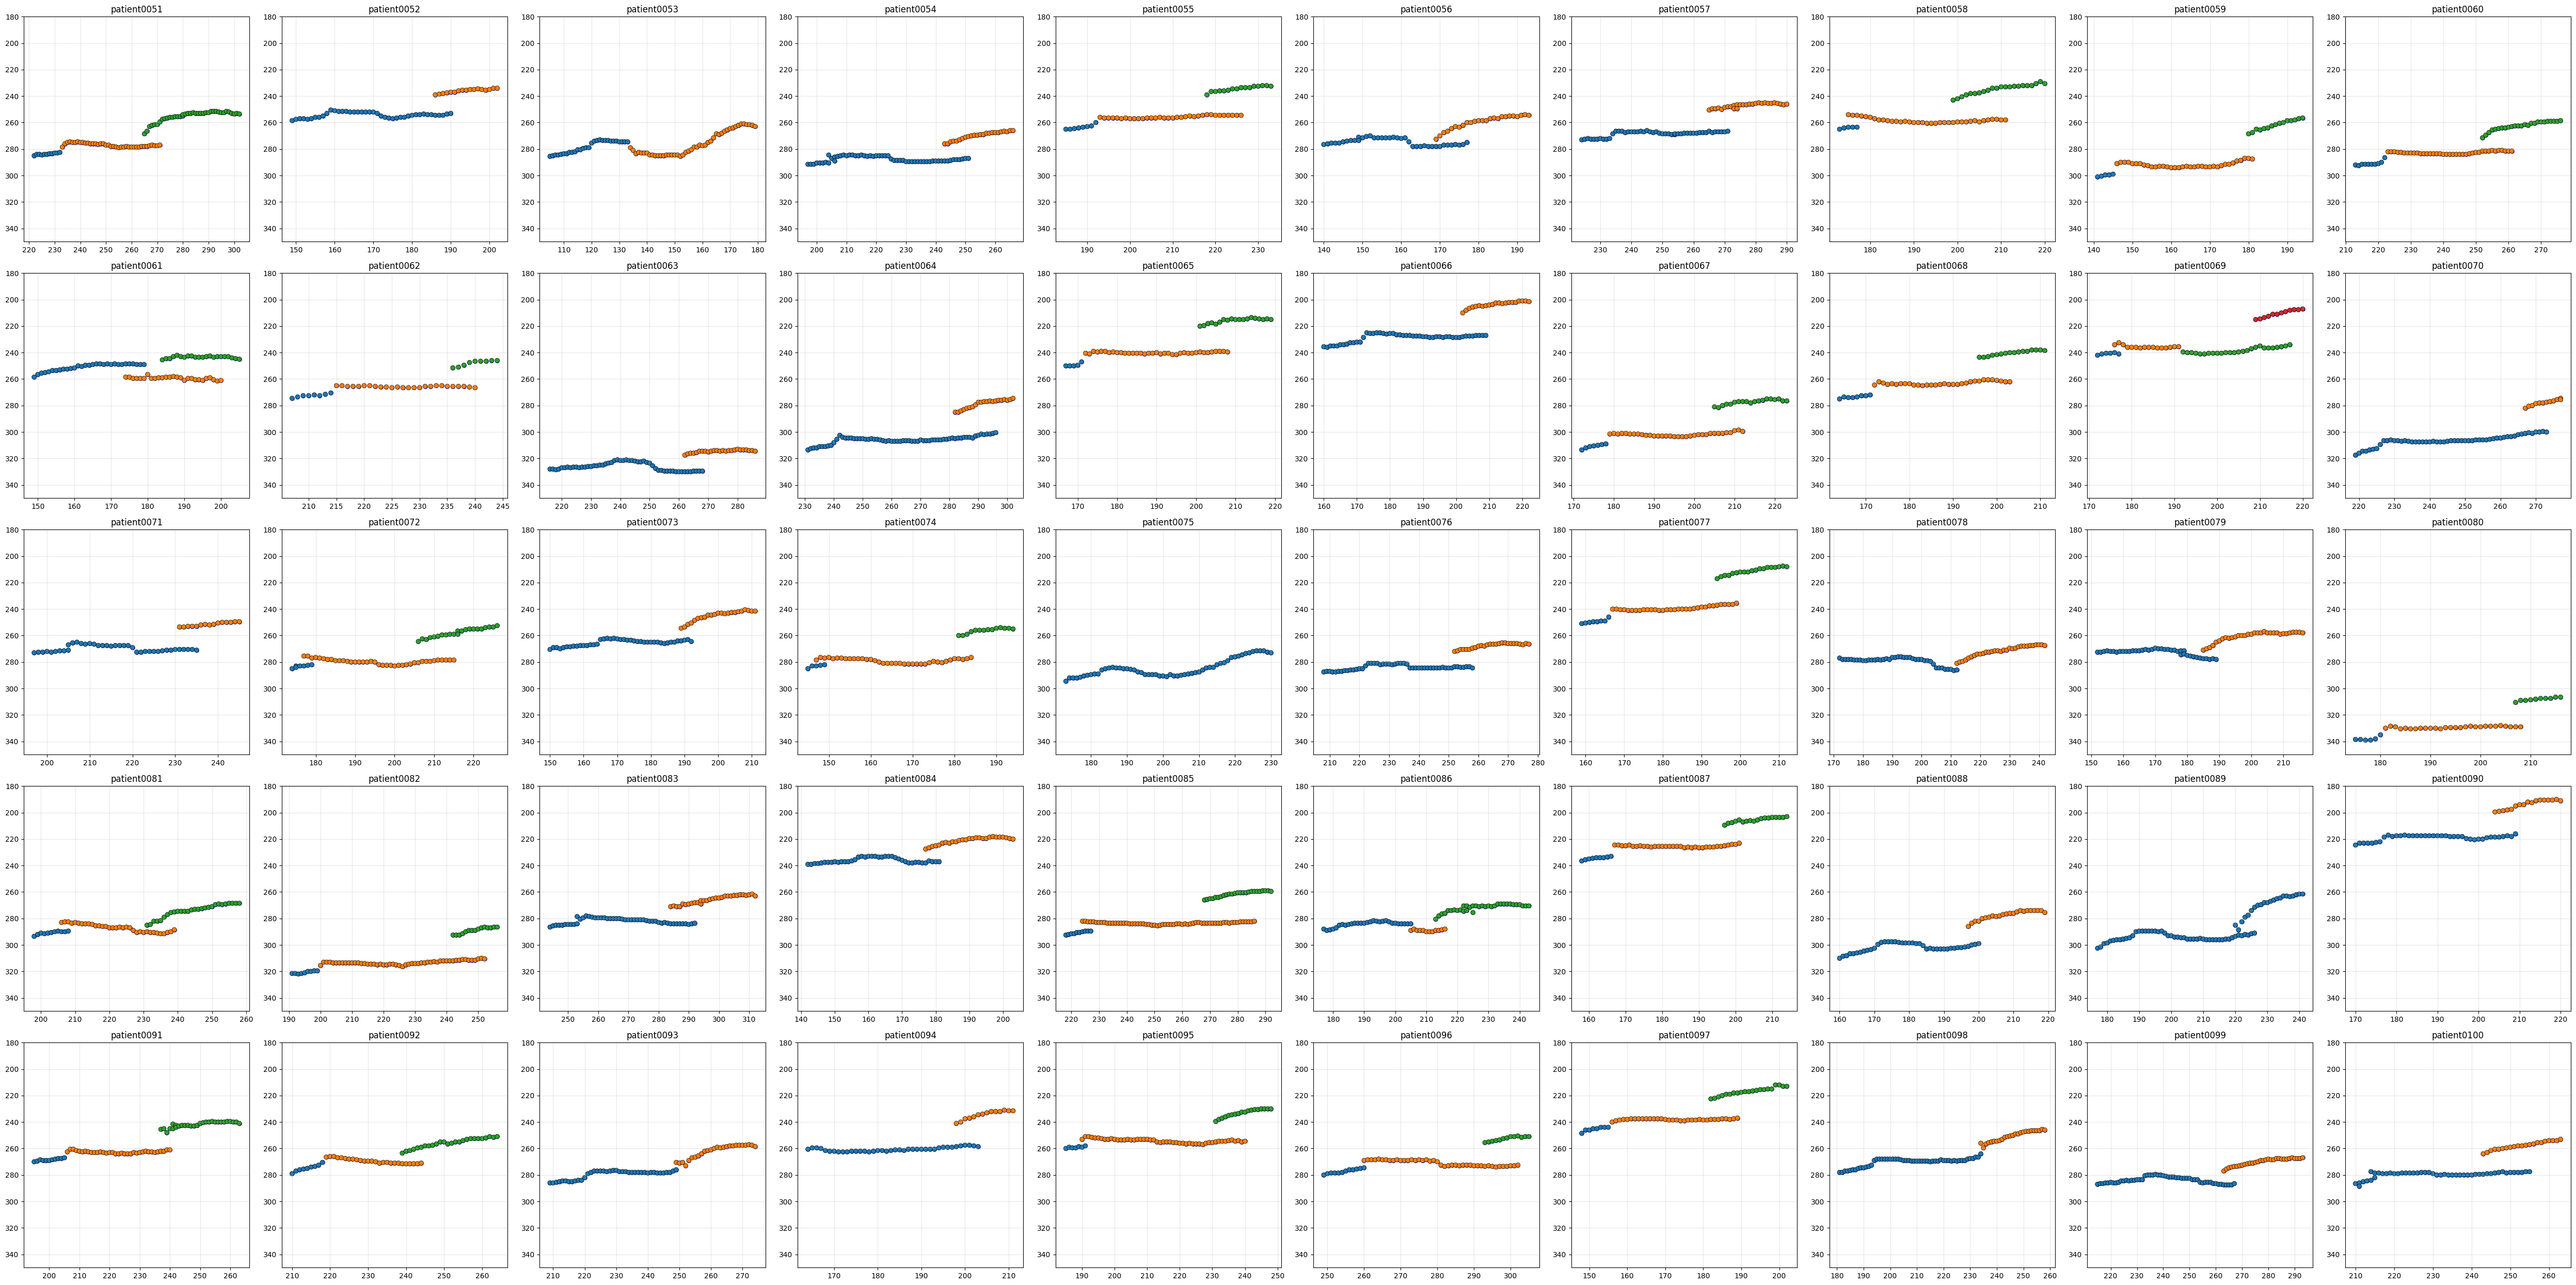

大圖已保存為 all_patients_clustering.png
聚類完成，50 個病人分析結束。

總結:
總刪除重複點: 0
總刪除離群點: 22
DBSCAN_clean_1130_v2_test.txt 已儲存


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np
import re
from matplotlib.gridspec import GridSpec

# 模擬 df_clean 數據（因為環境中無定義）
DBSCAN_updated_V2_name = "DBSCAN_clean_1130_v2_test.txt"

def process_patient_clusters(df_clean, P_ID):
    patient_data = df_clean[df_clean['patient_id'] == P_ID].copy()
    if patient_data.empty:
        return patient_data, 0, 0, 0
    
    patient_data = patient_data.sort_values('z_index')
    X = patient_data['z_index'].values
    Y = patient_data['y_center'].values
    points = np.column_stack((X, Y))
    
    # DBSCAN
    db = DBSCAN(eps=4, min_samples=1).fit(points)
    labels = db.labels_
    
    # 過濾簇大小 >10
    cluster_sizes = {}
    for label in set(labels):
        if label != -1:
            cluster_mask = (labels == label)
            cluster_size = np.sum(cluster_mask)
            cluster_sizes[label] = cluster_size
    
    deleted_duplicate = 0
    deleted_outlier = 0
    
    # 處理每個大簇
    for label, size in cluster_sizes.items():
        if size > 10:
            cluster_mask = (labels == label)
            cluster_data = patient_data[cluster_mask].copy()
            
            
#              # ---- 目前V2刪除這兩樣會造成下降，但不清楚是重複框刪到TP或是離群框砍到TP 需要再兩次的實驗＠＠ ---- #
#             # 第一：同 Z 重複框，Y_center 較小者刪除
#             for z in cluster_data['z_index'].unique():
#                 z_group = cluster_data[cluster_data['z_index'] == z]
#                 if len(z_group) > 1:
# #                     # 保留 Y_center 最大的 （下流）
# #                     keep_row = z_group.loc[z_group['y_center'].idxmax()]
#                     # 保留 Y_center 最小的 （上流）
#                     keep_row = z_group.loc[z_group['y_center'].idxmin()]
#                     delete_rows = z_group.drop(keep_row.name)
#                     deleted_duplicate += len(delete_rows)
#                     # 從 cluster_data 刪除
#                     cluster_data = cluster_data.drop(delete_rows.index)
            
            # 第二：刪除離主體間隔 >1 格的不連續離群點
            z_unique = sorted(cluster_data['z_index'].unique())
            gaps = np.diff(z_unique)
            outlier_indices = np.where(gaps > 1)[0]
            
            # 找出離群段（非主體段）
            segments = []
            start = 0
            for oi in outlier_indices:
                segments.append(z_unique[start:oi+1])
                start = oi + 1
            segments.append(z_unique[start:])
            
            # 主體段 = 最長段
            main_seg = max(segments, key=len)
            main_z_set = set(main_seg)
            
            # 刪除非主體段
            for seg in segments:
                if set(seg) != main_z_set and len(seg) <= 3:  # 小段離群才刪
                    for z in seg:
                        z_group = cluster_data[cluster_data['z_index'] == z]
                        deleted_outlier += len(z_group)
                        cluster_data = cluster_data.drop(z_group.index)
            
            # 更新 patient_data
            patient_data.loc[cluster_mask, :] = cluster_data
    
    return patient_data, deleted_duplicate, deleted_outlier, len(set(db.labels_) - {-1})

# 批量處理 patient0051 ~ patient0100
patients = [f'patient{i:04d}' for i in range(51, 101)]
updated_df = df_clean.copy()
deleted_duplicates_total = 0
deleted_outliers_total = 0

results = []
for P_ID in patients:
    filtered_data, del_dup, del_out, clusters = process_patient_clusters(df_clean, P_ID)
    # 更新 updated_df：替換該病人的數據為 filtered_data
    updated_df = updated_df[updated_df['patient_id'] != P_ID].copy()
    updated_df = pd.concat([updated_df, filtered_data], ignore_index=True)
    deleted_duplicates_total += del_dup
    deleted_outliers_total += del_out
    results.append((P_ID, del_dup, del_out, clusters))
    print(f"{P_ID}: 刪除重複 {del_dup}, 離群 {del_out}, 簇數 {clusters}")

# 儲存新 txt
# updated_df = updated_df.sort_values('confidence', ascending=False)
# for col in ['x1', 'y1', 'x2', 'y2']:
#     updated_df[col] = updated_df[col].fillna(0).round().astype(int)  # 填 NaN 避免錯誤
# updated_df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']].to_csv(DBSCAN_updated_V2_name, sep=' ', index=False, header=False, float_format='%.4f')
# 儲存新 txt（修正版：刪除 NaN 行，避免填充 0）
updated_df = updated_df.sort_values('confidence', ascending=False)

# Step 1: 檢查並刪除有 NaN 的行（直接移除，不填充 0）
updated_df = updated_df.dropna(subset=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2'])

# Step 2: 只對剩餘的座標欄位進行 round 和轉型（確保無 NaN）
for col in ['class', 'x1', 'y1', 'x2', 'y2']:
    updated_df[col] = updated_df[col].round().astype(int)

# Step 3: 選取欄位並儲存（無多餘行）
output_cols = ['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
updated_df[output_cols].to_csv(DBSCAN_updated_V2_name, sep=' ', index=False, header=False, float_format='%.4f')

print(f"儲存完成！總行數：{len(updated_df)}，無多餘 0 行。")
print(f"檔案：{DBSCAN_updated_V2_name}")




# 繪圖
# 繪圖大圖 (5x10 網格)
fig, axes = plt.subplots(5, 10, figsize=(50, 25))
axes = axes.ravel()
for i, P_ID in enumerate(patients):
    ax = axes[i]
    patient_data = updated_df[updated_df['patient_id'] == P_ID].copy()
    if patient_data.empty:
        ax.text(0.5, 0.5, 'No Data', ha='center')
        continue
   
    patient_data = patient_data.sort_values('z_index')
    X = patient_data['z_index'].values
    Y = patient_data['y_center'].values
    points = np.column_stack((X, Y))
   
    db = DBSCAN(eps=4, min_samples=1).fit(points)
    labels = db.labels_
    colors = ['red' if l == -1 else f'C{l}' for l in labels]
   
    ax.scatter(X, Y, c='blue', s=30, alpha=0.6, label='Original')
    ax.scatter(X, Y, c=colors, s=40, edgecolors='black', linewidth=0.5, label='Clustered')
    ax.set_title(P_ID)
    ax.set_ylim(350, 180)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_patients_clustering.png', dpi=150, bbox_inches='tight')
# plt.close()
plt.show()

# 輸出總結
print("大圖已保存為 all_patients_clustering.png")
print("聚類完成，50 個病人分析結束。")


print("\n總結:")
print(f"總刪除重複點: {deleted_duplicates_total}")
print(f"總刪除離群點: {deleted_outliers_total}")
print(f"{DBSCAN_updated_V2_name} 已儲存")

In [9]:
df_clean = updated_df


# DB clean V3
##### 接續步驟，另外寫一個新的處理function同樣使用已經處理好的df_clean當作輸入，針對patient0061的分群結果，不論分析後有多少群組(通常為2~4群)，若有兩群在Z軸位置上重疊超過20個框時，對其重疊的區域中Y軸值較大的群組，從x軸向前刪除12個框。繪製該病人子圖即可不用大圖，列印被刪除多少重複點，最後另存新的DBSCAN_clean_1129_v3.txt檔案。

In [10]:
# def process_patient0061_clusters(df_clean, DBSCAN_updated_V3_name='DBSCAN_clean_1129_v3.txt'):
#     """
#     新處理函式：針對 patient0061 的聚類結果進行刪除
#     """
#     from sklearn.cluster import DBSCAN
#     import matplotlib.pyplot as plt
    
#     # 提取 patient0061
#     patient_data = df_clean[df_clean['patient_id'] == 'patient0061'].copy()
#     patient_data = patient_data.sort_values('z_index')
    
#     if patient_data.empty:
#         print("patient0061 無數據")
#         return df_clean
    
#     original_count = len(patient_data)
#     print(f"原始點數：{original_count}")
    
#     # 聚類 (X=z_index, Y=y_center)
#     X = patient_data['z_index'].values
#     Y = patient_data['y_center'].values
#     points = np.column_stack((X, Y))
    
#     db = DBSCAN(eps=4, min_samples=1).fit(points)
#     labels = db.labels_
    
#     # 群組統計 (忽略噪聲 -1)
#     clusters = {}
#     for i, label in enumerate(labels):
#         if label != -1:
#             if label not in clusters:
#                 clusters[label] = []
#             clusters[label].append(i)
    
#     print(f"群組數：{len(clusters)}")
#     for label, idxs in clusters.items():
#         print(f"  簇 {label}: {len(idxs)} 點")
    
#     # 檢查重疊 (任意兩群 Z 重疊 >20)
#     overlap_groups = []
#     for label1 in clusters:
#         for label2 in clusters:
#             if label1 >= label2:
#                 continue
#             z1 = set(X[clusters[label1]])
#             z2 = set(X[clusters[label2]])
#             overlap_z = len(z1.intersection(z2))
#             if overlap_z > 10:
#                 overlap_groups.append((label1, label2, overlap_z))
    
#     if not overlap_groups:
#         print("無重疊群組 >20，無刪除")
#         return df_clean
    
#     print(f"重疊群組：{overlap_groups}")
    
#     # 選 Y 平均較大的群組，從其最小 Z 刪除  後 12 個
#     deleted_count = 0
#     for label1, label2, _ in overlap_groups:
#         # 計算平均 Y
#         y_avg1 = np.mean(Y[clusters[label1]])
#         y_avg2 = np.mean(Y[clusters[label2]])
        
#         # 選 Y 較大的群組
#         larger_label = label1 if y_avg1 > y_avg2 else label2
#         larger_idxs = clusters[larger_label]
        
#         # 從最小 Z 開始刪  後 14 個
#         sorted_larger = sorted(larger_idxs, key=lambda i: X[i])
#         # del 50% of overlap
#         cut_n = int(len(sorted_larger) / 2)
#         to_delete = sorted_larger[-cut_n:]
        
#         # 從 patient_data 刪除這些索引
#         patient_data = patient_data.drop(patient_data.index[to_delete])
#         deleted_count += len(to_delete)
    
#     print(f"被刪除重複點：{deleted_count} {cut_n}")
    
#     # 更新 df_clean (只改 patient0061)
#     df_clean.loc[df_clean['patient_id'] == 'patient0061', :] = np.nan  # 先清空
#     updated_df = pd.concat([df_clean, patient_data], ignore_index=True)
    
#     # 繪製子圖
#     fig, ax = plt.subplots(1, 1, figsize=(10, 6))
#     # 原始
#     ax.scatter(X, Y, c='blue', s=30, alpha=0.6, label='Original')
#     # 聚類
#     colors = ['red' if l == -1 else f'C{l}' for l in labels]
#     ax.scatter(X, Y, c=colors, s=40, edgecolors='black', linewidth=0.5, label='Clustered')
#     # 刪除後
#     remaining_X = patient_data['z_index'].values
#     remaining_Y = patient_data['y_center'].values
#     ax.scatter(remaining_X, remaining_Y, c='green', s=50, marker='^', label='After Deletion')
#     ax.set_title('patient0061: Z vs Y_center (Original + Clustered + Deleted)')
#     ax.set_xlabel('Z_index')
#     ax.set_ylabel('Y_center')
#     ax.set_ylim(350, 180)
#     ax.grid(True, alpha=0.3)
#     ax.legend()
#     plt.tight_layout()
#     plt.savefig('patient0061_updated_plot.png', dpi=150)
#     plt.show()
    
# #     # 儲存新 txt
# #     updated_df = df_clean.sort_values('confidence', ascending=False)
# #     for col in ['x1', 'y1', 'x2', 'y2']:
# #         updated_df[col] = updated_df[col].round().astype(int)
# #     updated_df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']].to_csv(output_txt, sep=' ', index=False, header=False, float_format='%.4f')
    
# #     print(f"新檔案儲存：{output_txt} (總行數 {len(updated_df)})")

#     # 儲存新 txt（修正版：刪除 NaN 行，避免 round/int 錯誤）
#     updated_df = updated_df.sort_values('confidence', ascending=False)

#     # Step 1: 刪除有 NaN 的行（直接移除，不填充 0）
#     updated_df = updated_df.dropna(subset=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2'])

#     # Step 2: 只對剩餘的座標欄位進行 round 和轉型（確保無 NaN）
#     for col in ['class', 'x1', 'y1', 'x2', 'y2']:
#         updated_df[col] = updated_df[col].round().astype(int)

#     # Step 3: 選取欄位並儲存
#     output_cols = ['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
#     updated_df[output_cols].to_csv(DBSCAN_updated_V3_name, sep=' ', index=False, header=False, float_format='%.4f')

#     print(f"儲存完成！總行數：{len(updated_df)}（已刪除 {original_count - len(updated_df)} 個 NaN 行）")
#     print(f"檔案：{DBSCAN_updated_V3_name}")
#     return df_clean


# # 使用方式
# DBSCAN_updated_V3_name = 'DBSCAN_clean_1130_v3.txt'
# updated_df_V3 = process_patient0061_clusters(df_clean, DBSCAN_updated_V3_name)

# DB clean V3-2

In [11]:
# df_clean = updated_df_V3
df_clean = updated_df


處理 patient0061: 前刪除 4, 後刪除 13
原始點數：80
群組數：3
  簇 0: 31 點
  簇 1: 27 點
  簇 2: 22 點
重疊群組：[(1, 2, 17)]
patient0061 被刪除重複點：17


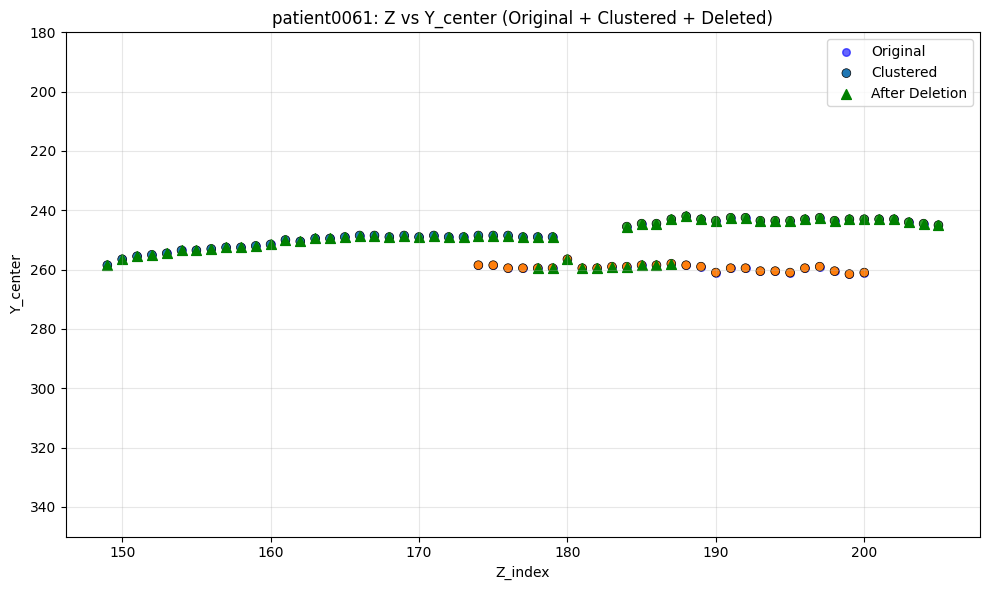


處理 patient0064: 前刪除 0, 後刪除 10
原始點數：87
群組數：2
  簇 0: 66 點
  簇 1: 21 點
重疊群組：[(0, 1, 15)]
patient0064 被刪除重複點：10


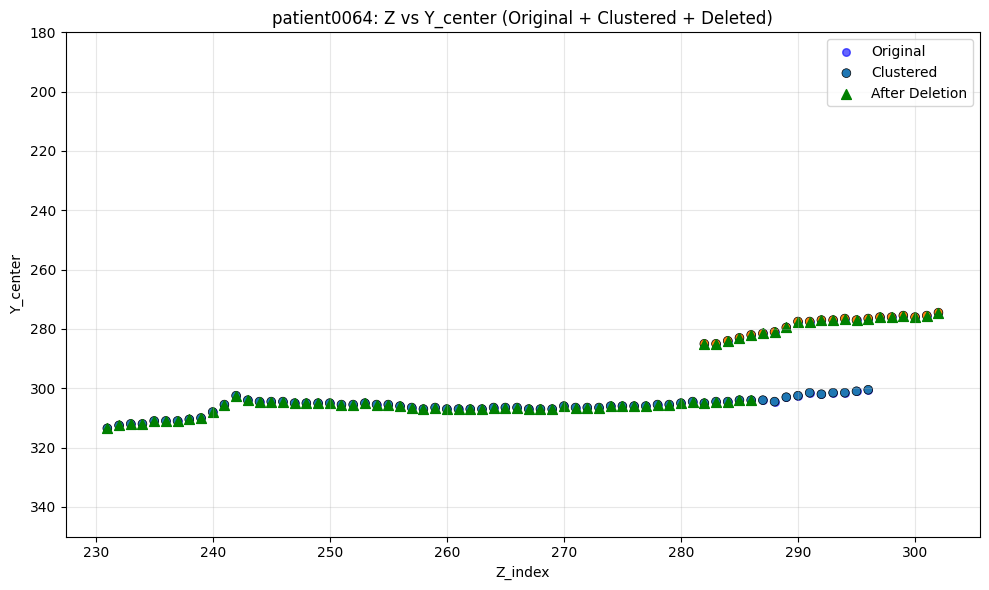


處理 patient0095: 前刪除 0, 後刪除 5
原始點數：76
群組數：3
  簇 0: 7 點
  簇 1: 51 點
  簇 2: 18 點
重疊群組：[(1, 2, 10)]
patient0095 被刪除重複點：5


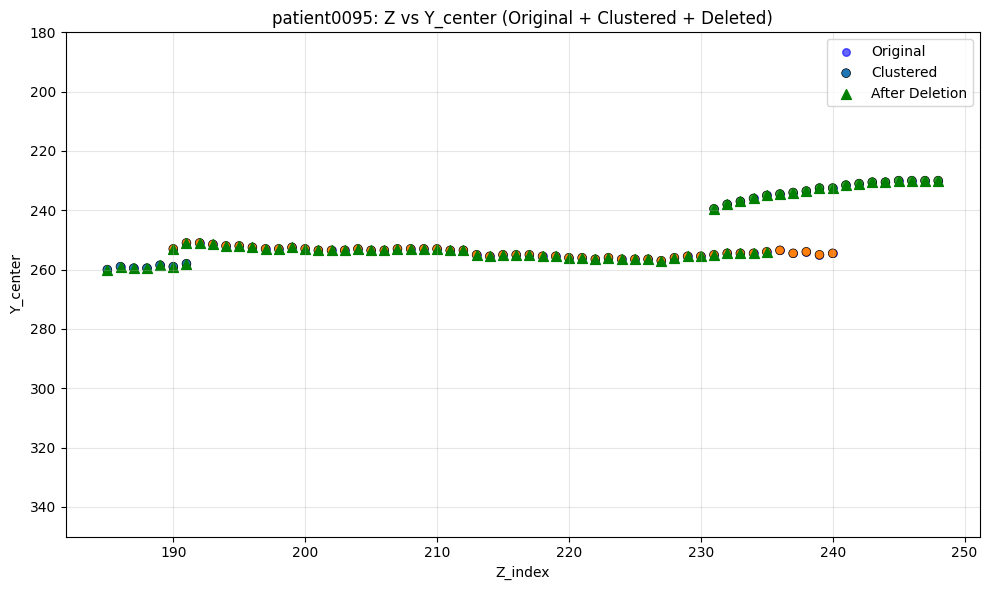


處理 patient0096: 前刪除 0, 後刪除 5
原始點數：68
群組數：3
  簇 0: 12 點
  簇 1: 43 點
  簇 2: 13 點
重疊群組：[(1, 2, 10)]
patient0096 被刪除重複點：5


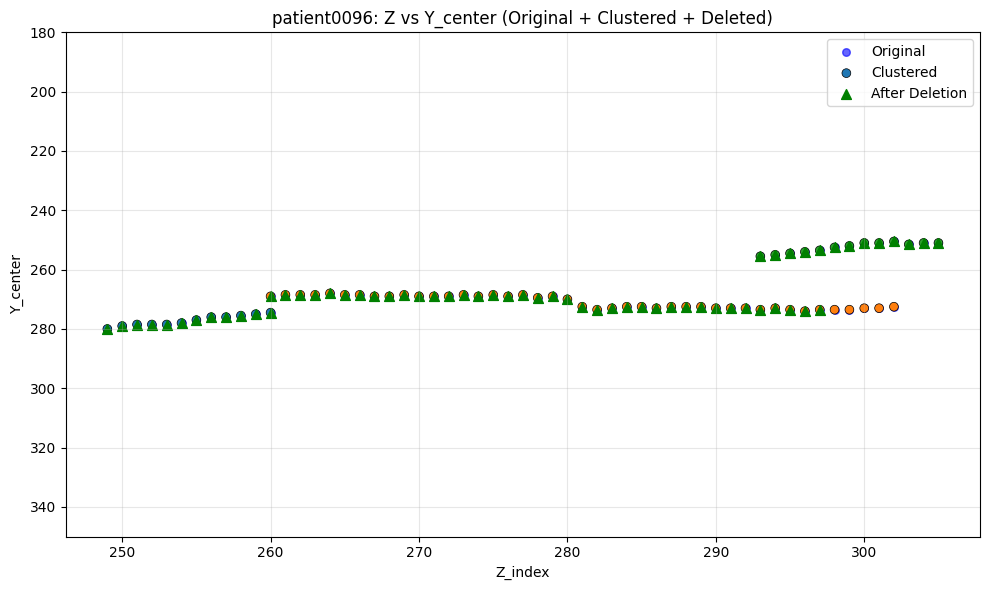


處理 patient0097: 前刪除 0, 後刪除 5
原始點數：63
群組數：3
  簇 0: 8 點
  簇 1: 34 點
  簇 2: 21 點
重疊群組：[(1, 2, 8)]
patient0097 被刪除重複點：5


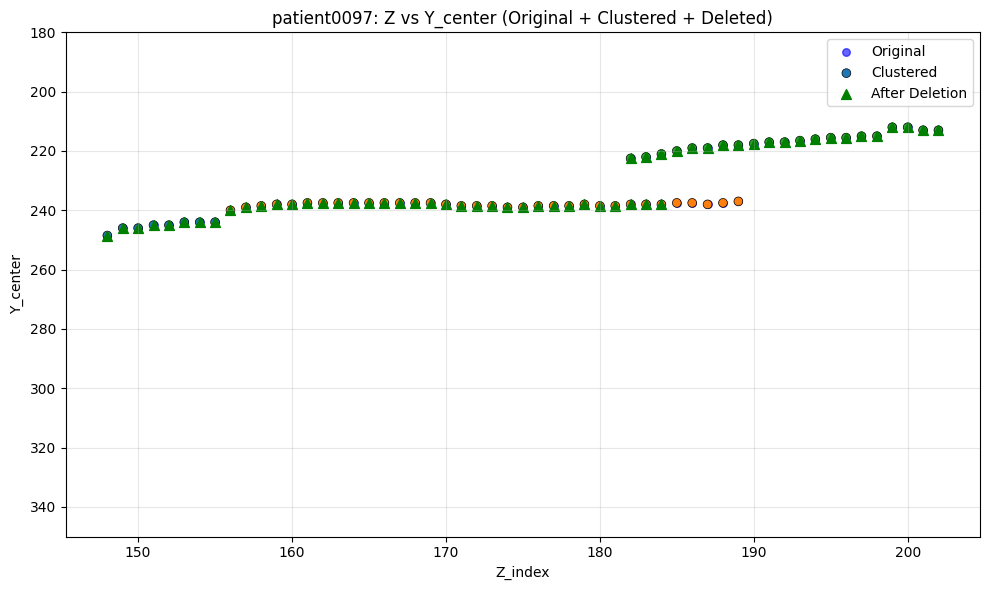


處理 patient0100: 前刪除 0, 後刪除 5
原始點數：70
群組數：2
  簇 0: 49 點
  簇 1: 21 點
重疊群組：[(0, 1, 13)]
patient0100 被刪除重複點：5


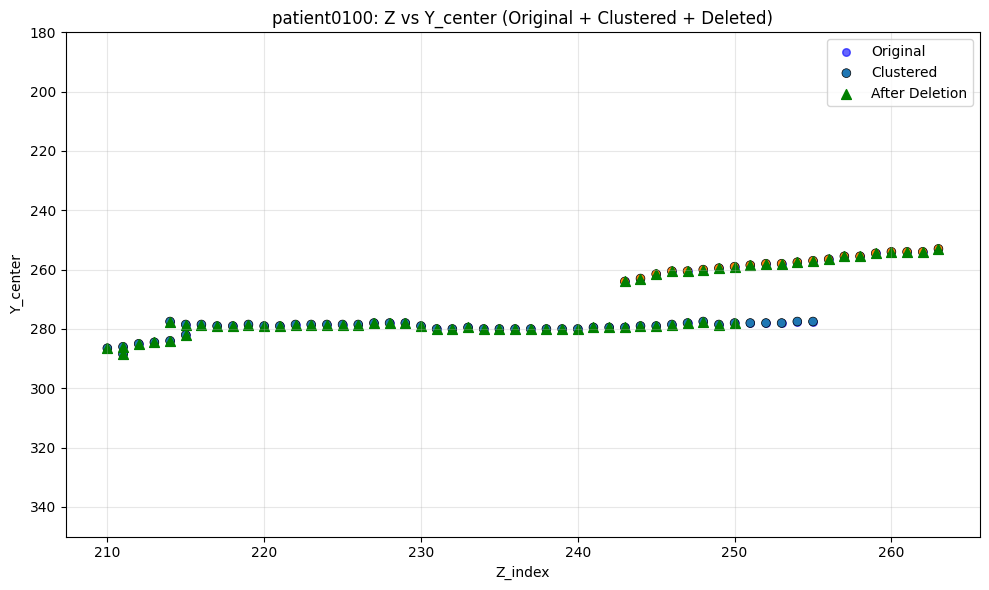


處理 patient0082: 前刪除 0, 後刪除 5
原始點數：77
群組數：3
  簇 0: 9 點
  簇 1: 53 點
  簇 2: 15 點
重疊群組：[(1, 2, 11)]
patient0082 被刪除重複點：5


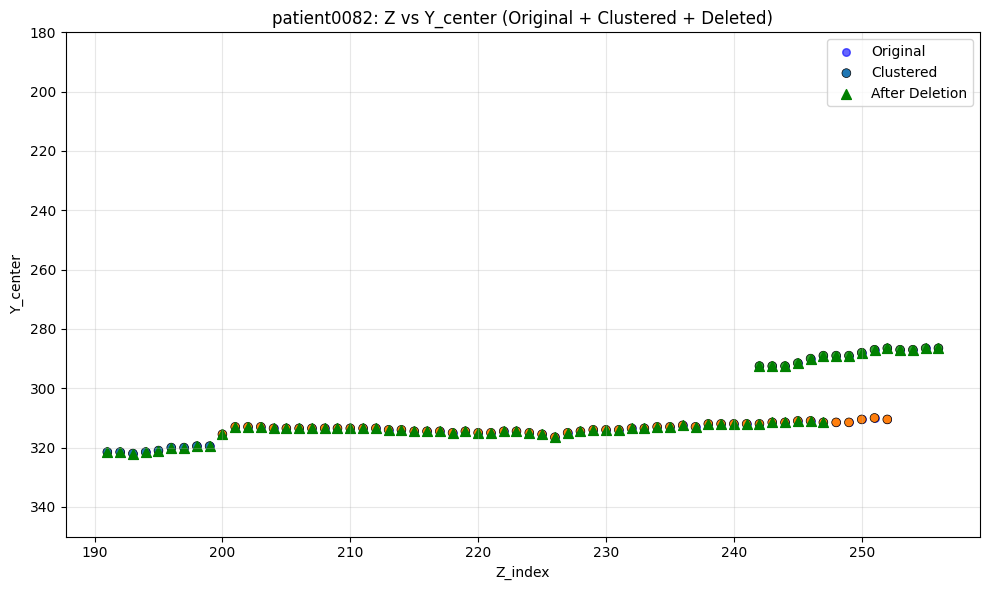


處理 patient0085: 前刪除 0, 後刪除 5
原始點數：98
群組數：3
  簇 0: 10 點
  簇 1: 63 點
  簇 2: 25 點
重疊群組：[(1, 2, 19)]
patient0085 被刪除重複點：5


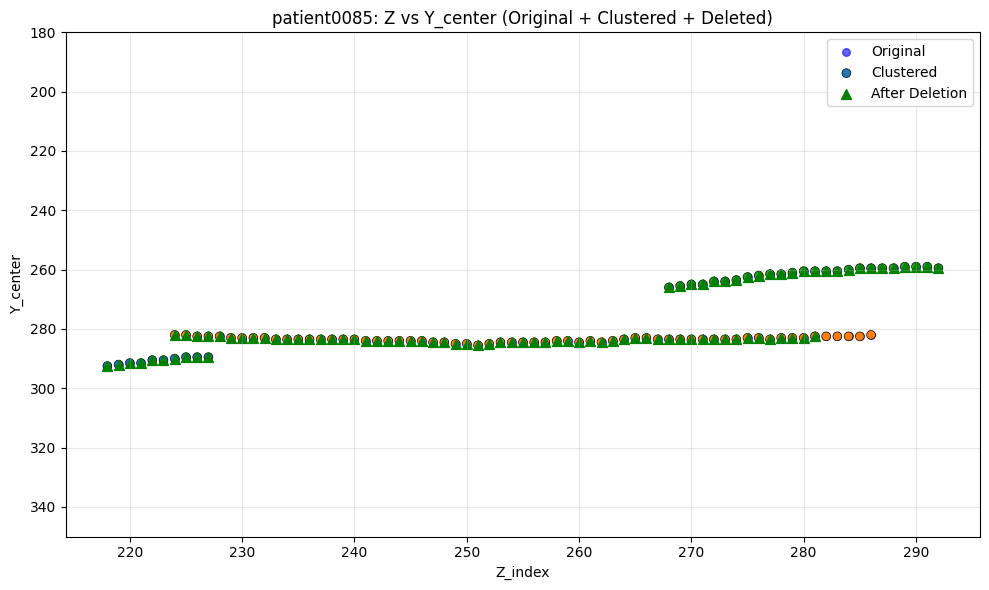


處理 patient0065: 前刪除 0, 後刪除 5
原始點數：61
群組數：3
  簇 0: 5 點
  簇 1: 37 點
  簇 2: 19 點
重疊群組：[(1, 2, 8)]
patient0065 被刪除重複點：5


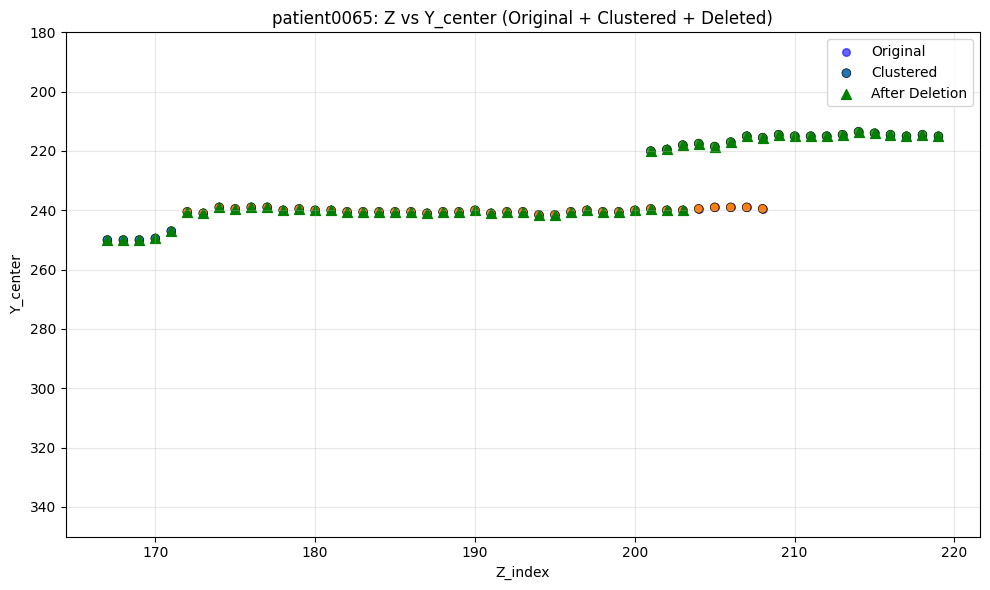


處理 patient0066: 前刪除 0, 後刪除 5
原始點數：71
群組數：2
  簇 0: 50 點
  簇 1: 21 點
重疊群組：[(0, 1, 8)]
patient0066 被刪除重複點：5


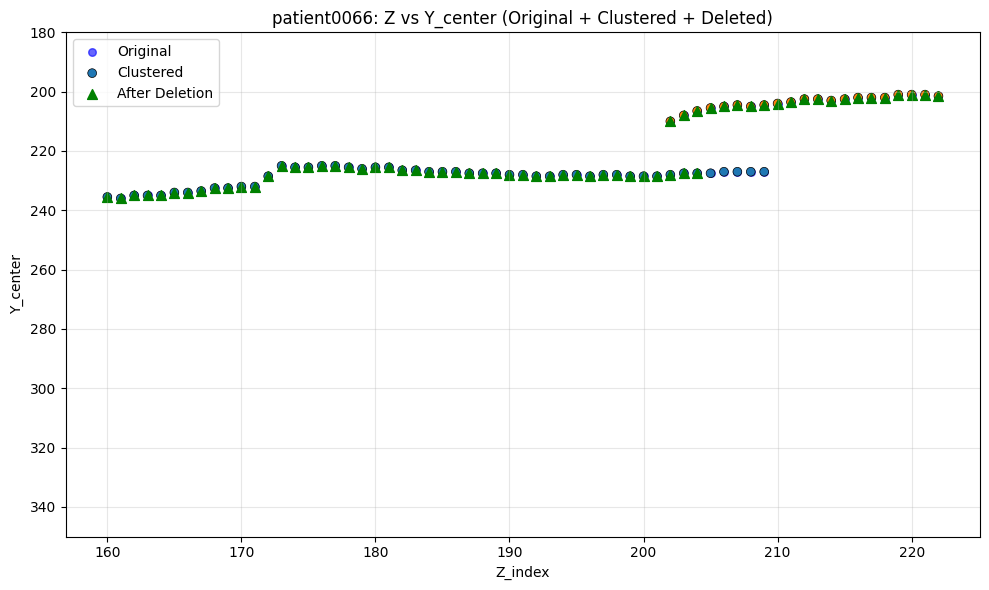


處理 patient0058: 前刪除 0, 後刪除 5
原始點數：64
群組數：3
  簇 0: 5 點
  簇 1: 37 點
  簇 2: 22 點
重疊群組：[(1, 2, 13)]
patient0058 被刪除重複點：5


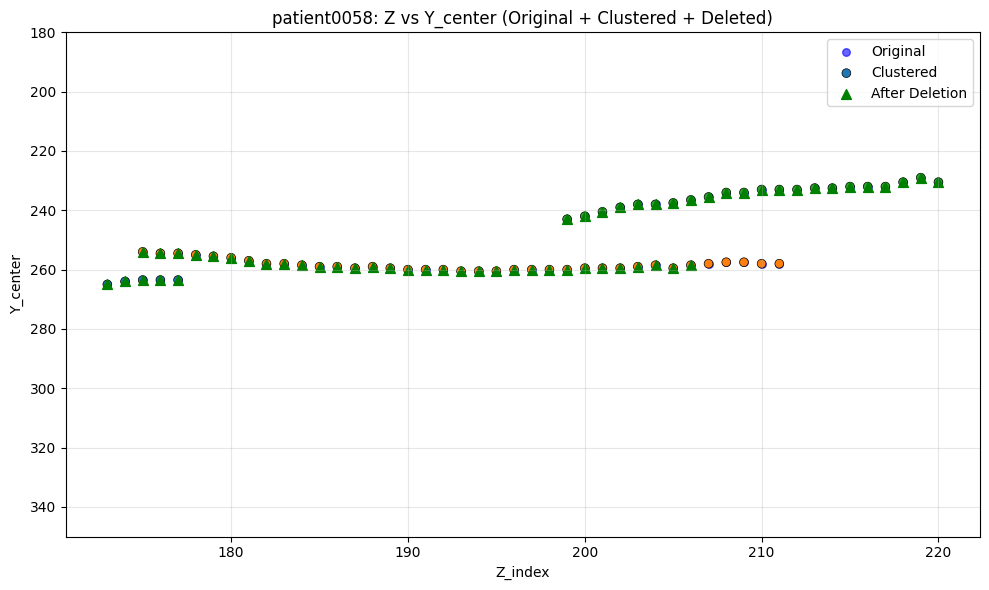


總刪除重複點：72
新檔案儲存：DBSCAN_clean_1130_v3_2_3.txt (總行數 3339)


In [12]:
def process_patients_clusters(df_clean, patient_list, delete_params, output_txt='DBSCAN_clean_1130_v3.txt'):
    """
    新處理函式：針對多個病人的聚類結果進行刪除
    patient_list: 病人 ID 列表 e.g., ['patient0061', 'patient0064', 'patient0095', 'patient0096']
    delete_params: 每個病人的 (前刪除數, 後刪除數) 列表 e.g., [(2,13), (0,10), (1,14), (0,13)]
    """
    from sklearn.cluster import DBSCAN
    import matplotlib.pyplot as plt
    import numpy as np
    import re
    
    if len(patient_list) != len(delete_params):
        print("錯誤：patient_list 與 delete_params 長度不匹配！")
        return df_clean
    
    deleted_total = 0
    for i, P_ID in enumerate(patient_list):
        front_del, back_del = delete_params[i]
        print(f"\n處理 {P_ID}: 前刪除 {front_del}, 後刪除 {back_del}")
        
        # 提取病人數據
        patient_data = df_clean[df_clean['patient_id'] == P_ID].copy()
        patient_data = patient_data.sort_values('z_index')
        
        if patient_data.empty:
            print(f"{P_ID} 無數據，跳過")
            continue
        
        original_count = len(patient_data)
        print(f"原始點數：{original_count}")
        
        # 聚類 (X=z_index, Y=y_center)
        X = patient_data['z_index'].values
        Y = patient_data['y_center'].values
        points = np.column_stack((X, Y))
        
        db = DBSCAN(eps=4, min_samples=1).fit(points)
        labels = db.labels_
        
        # 群組統計 (忽略噪聲 -1)
        clusters = {}
        for j, label in enumerate(labels):
            if label != -1:
                if label not in clusters:
                    clusters[label] = []
                clusters[label].append(j)
        
        print(f"群組數：{len(clusters)}")
        for label, idxs in clusters.items():
            print(f"  簇 {label}: {len(idxs)} 點")
        
        # 檢查重疊 (任意兩群 Z 重疊 >10)
        overlap_groups = []
        for label1 in clusters:
            for label2 in clusters:
                if label1 >= label2:
                    continue
                z1 = set(X[clusters[label1]])
                z2 = set(X[clusters[label2]])
                overlap_z = len(z1.intersection(z2))
                if overlap_z >= 8:
                    overlap_groups.append((label1, label2, overlap_z))
        
        if not overlap_groups:
            print("無重疊群組 >10，無刪除")
            continue
        
        print(f"重疊群組：{overlap_groups}")
        
        # 選 Y 平均較大的群組，從最小 Z 刪除前 N 個，從最大 Z 刪除後 M 個
        deleted_count = 0
        for label1, label2, _ in overlap_groups:
            # 計算平均 Y
            y_avg1 = np.mean(Y[clusters[label1]])
            y_avg2 = np.mean(Y[clusters[label2]])
            
            # 選 Y 較大的群組
            larger_label = label1 if y_avg1 > y_avg2 else label2
            larger_idxs = clusters[larger_label]
            
            # 從最小 Z 開始刪除前 N 個
            sorted_larger = sorted(larger_idxs, key=lambda j: X[j])
            to_delete_front = sorted_larger[:front_del]
            
            # 從最大 Z 開始刪除後 M 個
            to_delete_back = sorted_larger[-back_del:]
            
            # 合併刪除索引
            to_delete = list(set(to_delete_front + to_delete_back))  # 避免重複
            patient_data = patient_data.drop(patient_data.index[to_delete])
            deleted_count += len(to_delete)
        
        print(f"{P_ID} 被刪除重複點：{deleted_count}")
        deleted_total += deleted_count
        
        # 更新 df_clean (只改此病人)
        df_clean = df_clean[df_clean['patient_id'] != P_ID].copy()
        df_clean = pd.concat([df_clean, patient_data], ignore_index=True)
        
        # 繪製子圖
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # 原始
        ax.scatter(X, Y, c='blue', s=30, alpha=0.6, label='Original')
        # 聚類
        colors = ['red' if l == -1 else f'C{l}' for l in labels]
        ax.scatter(X, Y, c=colors, s=40, edgecolors='black', linewidth=0.5, label='Clustered')
        # 刪除後
        remaining_X = patient_data['z_index'].values
        remaining_Y = patient_data['y_center'].values
        ax.scatter(remaining_X, remaining_Y, c='green', s=50, marker='^', label='After Deletion')
        ax.set_title(f'{P_ID}: Z vs Y_center (Original + Clustered + Deleted)')
        ax.set_xlabel('Z_index')
        ax.set_ylabel('Y_center')
        ax.set_ylim(350, 180)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'{P_ID}_updated_plot.png', dpi=150)
        plt.show()
    
    # 儲存新 txt（修正版：刪除 NaN 行，避免 round/int 錯誤）
    updated_df = df_clean.sort_values('confidence', ascending=False)
    # Step 1: 刪除有 NaN 的行
    updated_df = updated_df.dropna(subset=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2'])
    # Step 2: 對座標欄位進行 round + int
    for col in ['x1', 'y1', 'x2', 'y2']:
        updated_df[col] = pd.to_numeric(updated_df[col], errors='coerce').round().fillna(0).astype(int)
    # Step 3: 儲存
    output_cols = ['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
    updated_df[output_cols].to_csv(output_txt, sep=' ', index=False, header=False, float_format='%.4f')
    
    print(f"\n總刪除重複點：{deleted_total}")
    print(f"新檔案儲存：{output_txt} (總行數 {len(updated_df)})")
    return df_clean

# 使用方式
# patient_list = ['patient0061', 'patient0064', 'patient0095', 'patient0096']
patient_list = ['patient0061', 'patient0064', 'patient0095', 'patient0096', 'patient0097', 'patient0100', 'patient0082', 'patient0085', 'patient0065', 'patient0066', 'patient0058', ]
delete_params = [(4,13), (0,10), (0,5), (0,5), (0,5), (0,5), (0,5), (0,5), (0,5), (0,5), (0,5)]
DBSCAN_updated_V3_name = 'DBSCAN_clean_1130_v3_2_3.txt'
updated_df_V3_2 = process_patients_clusters(df_clean, patient_list, delete_params, DBSCAN_updated_V3_name)